# 07. XGBoost 비선형 모델링
## XGBoost Modeling for Semiconductor Fail Prediction

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

이전 단계에서는 Logistic Regression을 기반으로
클래스 불균형 처리와 Feature Selection을 수행하였다.

그러나 다음과 같은 한계가 확인되었다.

- Baseline Logistic Regression의 Fail Recall은 14.29%에 그쳤다.
- SMOTE 1:1 적용 후에도 Fail Recall은 개선되지 않았다.
- Mutual Information 기반 Feature Selection에서도
  전체 442개 Feature를 사용하는 경우가 가장 높은 CV PR-AUC를 기록하였다.

따라서 본 단계에서는 선형 결정경계를 사용하는 Logistic Regression에서 벗어나
비선형 관계와 센서 변수 간 상호작용을 학습할 수 있는 XGBoost를 적용한다.

본 Notebook에서는 다음 두 모델을 비교한다.

1. 기본 XGBoost
2. `scale_pos_weight`를 적용한 XGBoost

주요 평가 기준은 다음과 같다.

- Fail Recall
- False Negative
- Precision
- F1/F2-score
- PR-AUC
- ROC-AUC

Hyperparameter Tuning은 다음 단계에서 별도로 수행하며,
본 단계에서는 기본적인 XGBoost 적용 효과와
클래스 가중치 조정의 영향을 우선 확인한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. 데이터 준비

이전 모델과 공정한 비교를 위해 동일한 데이터 분할 조건을 유지한다.

- Test Size: 20%
- `random_state=42`
- `stratify=y`

또한 Feature 품질 제거 기준은 Test Data에서 계산하지 않고,
Training Data를 기준으로 결정한다.

이전 Feature Selection 결과에서 Mutual Information 기반으로
Feature 수를 추가적으로 줄였을 때 성능 개선이 확인되지 않았으므로,
본 단계에서는 품질 필터 이후 유지되는 전체 센서 Feature를 사용한다.

In [2]:
DATA_PATH = Path(
    "../data/processed/uci-secom.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1567, 592)


In [3]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[feature_cols].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(
    y.value_counts()
    .sort_index()
)

X shape: (1567, 590)
y shape: (1567,)

Target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(
    f"\nTrain Fail Rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Test Fail Rate : "
    f"{y_test.mean() * 100:.2f}%"
)

X_train: (1253, 590)
X_test : (314, 590)

Train Fail Rate: 6.62%
Test Fail Rate : 6.69%


## 2. Feature 품질 필터

XGBoost 모델에서도 이전 전처리 단계와 동일하게
다음 센서 변수들을 제거한다.

1. Training Data에서 결측률이 40% 이상인 변수
2. 모든 값이 결측인 변수
3. 하나의 값만 가지는 비정보 변수

Feature 제거 기준은 Pipeline의 `fit()` 과정에서
Training Data를 이용하여 학습된다.

Test Data에는 Training Data에서 결정된 동일한 Feature 목록을 적용한다.

In [5]:
class FeatureQualityFilter(
    BaseEstimator,
    TransformerMixin
):
    def __init__(
        self,
        missing_threshold=40.0
    ):
        self.missing_threshold = (
            missing_threshold
        )

    def fit(self, X, y=None):

        X = pd.DataFrame(X).copy()

        missing_ratio = (
            X.isna()
            .mean()
            .mul(100)
        )

        high_missing = (
            missing_ratio[
                missing_ratio
                >= self.missing_threshold
            ]
            .index
            .tolist()
        )

        all_missing = [
            col for col in X.columns
            if X[col].isna().all()
        ]

        single_value = [
            col for col in X.columns
            if X[col].nunique(
                dropna=True
            ) == 1
        ]

        self.features_to_remove_ = sorted(
            set(
                high_missing
                + all_missing
                + single_value
            )
        )

        self.features_to_keep_ = [
            col for col in X.columns
            if col
            not in self.features_to_remove_
        ]

        self.feature_names_in_ = np.array(
            X.columns,
            dtype=object
        )

        return self

    def transform(self, X):

        X = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        ).copy()

        return X[
            self.features_to_keep_
        ]

    def get_feature_names_out(
        self,
        input_features=None
    ):
        return np.array(
            self.features_to_keep_,
            dtype=object
        )

In [6]:
quality_filter_preview = FeatureQualityFilter(
    missing_threshold=40
)

quality_filter_preview.fit(
    X_train
)

print(
    "Original features:",
    X_train.shape[1]
)

print(
    "Features removed:",
    len(
        quality_filter_preview
        .features_to_remove_
    )
)

print(
    "Features retained:",
    len(
        quality_filter_preview
        .features_to_keep_
    )
)

Original features: 590
Features removed: 148
Features retained: 442


## 3. 기본 XGBoost 모델

먼저 클래스 가중치를 별도로 조정하지 않은
기본 XGBoost 모델을 구축한다.

본 단계의 목적은 최적 모델을 만드는 것이 아니라,
비선형 Tree Boosting 모델 자체가 기존 Logistic Regression보다
Fail 패턴을 더 잘 학습할 수 있는지 확인하는 것이다.

따라서 본 단계에서는 복잡한 Hyperparameter Tuning을 수행하지 않는다.

XGBoost 모델에는 다음 전처리 과정만 적용한다.

1. Feature 품질 필터
2. Median Imputation
3. XGBoost

Tree 기반 모델은 변수 간 거리 계산을 기반으로 하지 않으므로
본 XGBoost Pipeline에서는 Standard Scaling을 사용하지 않는다.

In [7]:
xgb_base_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

print(xgb_base_pipeline)

Pipeline(steps=[('quality_filter', FeatureQualityFilter(missing_threshold=40)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_...None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                  

In [8]:
xgb_base_pipeline.fit(
    X_train,
    y_train
)

print(
    "Base XGBoost training completed."
)

Base XGBoost training completed.


In [9]:
base_model_is_fitted = hasattr(
    xgb_base_pipeline.named_steps[
        "model"
    ],
    "feature_importances_"
)

print(
    "Model fitted:",
    base_model_is_fitted
)

Model fitted: True


In [10]:
xgb_base_pred = (
    xgb_base_pipeline.predict(
        X_test
    )
)

xgb_base_prob = (
    xgb_base_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

print(
    "Predictions:",
    len(xgb_base_pred)
)

Predictions: 314


In [11]:
xgb_base_accuracy = accuracy_score(
    y_test,
    xgb_base_pred
)

xgb_base_precision = precision_score(
    y_test,
    xgb_base_pred,
    zero_division=0
)

xgb_base_recall = recall_score(
    y_test,
    xgb_base_pred,
    zero_division=0
)

xgb_base_f1 = f1_score(
    y_test,
    xgb_base_pred,
    zero_division=0
)

xgb_base_f2 = fbeta_score(
    y_test,
    xgb_base_pred,
    beta=2,
    zero_division=0
)

xgb_base_pr_auc = average_precision_score(
    y_test,
    xgb_base_prob
)

xgb_base_roc_auc = roc_auc_score(
    y_test,
    xgb_base_prob
)

print(
    f"Accuracy  : {xgb_base_accuracy:.4f}"
)
print(
    f"Precision : {xgb_base_precision:.4f}"
)
print(
    f"Recall    : {xgb_base_recall:.4f}"
)
print(
    f"F1-score  : {xgb_base_f1:.4f}"
)
print(
    f"F2-score  : {xgb_base_f2:.4f}"
)
print(
    f"PR-AUC    : {xgb_base_pr_auc:.4f}"
)
print(
    f"ROC-AUC   : {xgb_base_roc_auc:.4f}"
)

Accuracy  : 0.9299
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
F2-score  : 0.0000
PR-AUC    : 0.1881
ROC-AUC   : 0.7444


In [12]:
xgb_base_cm = confusion_matrix(
    y_test,
    xgb_base_pred
)

print(xgb_base_cm)

[[292   1]
 [ 21   0]]


## 4. XGBoost 클래스 가중치 계산

기본 XGBoost는 Pass와 Fail 샘플의 손실에 별도의 상대 가중치를 적용하지 않는다.

그러나 Training Data에서 Fail은 소수 클래스이므로
모델이 다수 클래스인 Pass 중심으로 학습될 가능성이 있다.

이를 보완하기 위해 XGBoost의 `scale_pos_weight`를 적용한다.

초기 실험에서는 다음 비율을 사용한다.

`scale_pos_weight = Pass 샘플 수 / Fail 샘플 수`

이 값은 불균형 분류에서 사용할 수 있는 대표적인 초기 후보값이며,
최적값은 이후 Hyperparameter Tuning 단계에서 별도로 탐색한다.

In [13]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "Pass samples:",
    negative_count
)

print(
    "Fail samples:",
    positive_count
)

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.4f}"
)

Pass samples: 1170
Fail samples: 83
scale_pos_weight: 14.0964


## 5. `scale_pos_weight` 적용 XGBoost

두 번째 XGBoost 모델에서는
Fail 클래스에 더 높은 상대 가중치를 부여한다.

다른 조건은 기본 XGBoost와 동일하게 유지하고,
`scale_pos_weight`만 변경한다.

이를 통해 성능 차이가 클래스 가중치 적용에 의해 발생하도록
실험 조건을 통제한다.

주요 관심 항목은 다음과 같다.

- Fail Recall이 증가하는가?
- False Negative가 감소하는가?
- Precision은 얼마나 변화하는가?
- PR-AUC는 개선되는가?

In [14]:
xgb_weighted_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        )
    )
])

print(xgb_weighted_pipeline)

Pipeline(steps=[('quality_filter', FeatureQualityFilter(missing_threshold=40)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_...None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                  

In [15]:
xgb_weighted_pipeline.fit(
    X_train,
    y_train
)

print(
    "Weighted XGBoost training completed."
)

Weighted XGBoost training completed.


In [16]:
xgb_weighted_pred = (
    xgb_weighted_pipeline.predict(
        X_test
    )
)

xgb_weighted_prob = (
    xgb_weighted_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

print(
    "Predictions:",
    len(xgb_weighted_pred)
)

Predictions: 314


In [17]:
xgb_weighted_accuracy = accuracy_score(
    y_test,
    xgb_weighted_pred
)

xgb_weighted_precision = precision_score(
    y_test,
    xgb_weighted_pred,
    zero_division=0
)

xgb_weighted_recall = recall_score(
    y_test,
    xgb_weighted_pred,
    zero_division=0
)

xgb_weighted_f1 = f1_score(
    y_test,
    xgb_weighted_pred,
    zero_division=0
)

xgb_weighted_f2 = fbeta_score(
    y_test,
    xgb_weighted_pred,
    beta=2,
    zero_division=0
)

xgb_weighted_pr_auc = (
    average_precision_score(
        y_test,
        xgb_weighted_prob
    )
)

xgb_weighted_roc_auc = (
    roc_auc_score(
        y_test,
        xgb_weighted_prob
    )
)

print(
    f"Accuracy  : "
    f"{xgb_weighted_accuracy:.4f}"
)
print(
    f"Precision : "
    f"{xgb_weighted_precision:.4f}"
)
print(
    f"Recall    : "
    f"{xgb_weighted_recall:.4f}"
)
print(
    f"F1-score  : "
    f"{xgb_weighted_f1:.4f}"
)
print(
    f"F2-score  : "
    f"{xgb_weighted_f2:.4f}"
)
print(
    f"PR-AUC    : "
    f"{xgb_weighted_pr_auc:.4f}"
)
print(
    f"ROC-AUC   : "
    f"{xgb_weighted_roc_auc:.4f}"
)

Accuracy  : 0.9299
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
F2-score  : 0.0000
PR-AUC    : 0.1562
ROC-AUC   : 0.7065


In [18]:
xgb_weighted_cm = confusion_matrix(
    y_test,
    xgb_weighted_pred
)

print(xgb_weighted_cm)

[[292   1]
 [ 21   0]]


In [19]:
print(
    classification_report(
        y_test,
        xgb_weighted_pred,
        target_names=[
            "Pass",
            "Fail"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Pass       0.93      1.00      0.96       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



## 6. XGBoost 모델 성능 비교

기본 XGBoost와 클래스 가중치를 적용한 XGBoost의
성능을 비교한다.

Accuracy만으로 모델을 판단하지 않고,
Fail 검출과 직접 관련된 Recall, F2-score,
PR-AUC 및 False Negative를 중심으로 분석한다.

특히 `scale_pos_weight` 적용 후
Recall 향상의 대가로 False Positive가 지나치게 증가하는지도 함께 확인한다.

In [20]:
base_tn, base_fp, \
base_fn, base_tp = (
    xgb_base_cm.ravel()
)

weighted_tn, weighted_fp, \
weighted_fn, weighted_tp = (
    xgb_weighted_cm.ravel()
)

xgb_results = pd.DataFrame({
    "Model": [
        "Base XGBoost",
        "XGBoost + scale_pos_weight"
    ],

    "Accuracy": [
        xgb_base_accuracy,
        xgb_weighted_accuracy
    ],

    "Precision": [
        xgb_base_precision,
        xgb_weighted_precision
    ],

    "Recall": [
        xgb_base_recall,
        xgb_weighted_recall
    ],

    "F1": [
        xgb_base_f1,
        xgb_weighted_f1
    ],

    "F2": [
        xgb_base_f2,
        xgb_weighted_f2
    ],

    "PR-AUC": [
        xgb_base_pr_auc,
        xgb_weighted_pr_auc
    ],

    "ROC-AUC": [
        xgb_base_roc_auc,
        xgb_weighted_roc_auc
    ],

    "False Negatives": [
        base_fn,
        weighted_fn
    ],

    "True Positives": [
        base_tp,
        weighted_tp
    ],

    "False Positives": [
        base_fp,
        weighted_fp
    ]
})

xgb_results.round(4)

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives,False Positives
0,Base XGBoost,0.9299,0.0,0.0,0.0,0.0,0.1881,0.7444,21,0,1
1,XGBoost + scale_pos_weight,0.9299,0.0,0.0,0.0,0.0,0.1562,0.7065,21,0,1


In [21]:
XGB_RESULT_PATH = Path(
    "../results/metrics/"
    "xgboost_model_results.csv"
)

xgb_results.to_csv(
    XGB_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    XGB_RESULT_PATH
)

print(
    "File exists:",
    XGB_RESULT_PATH.exists()
)

Saved to: ..\results\metrics\xgboost_model_results.csv
File exists: True


In [22]:
BASELINE_RESULT_PATH = Path(
    "../results/metrics/"
    "baseline_model_results.csv"
)

baseline_results = pd.read_csv(
    BASELINE_RESULT_PATH
)

baseline_results

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC
0,Dummy Classifier,0.933121,0.000,0.000000,0.000000,0.000000,0.066879,0.50000
1,Logistic Regression,0.875796,0.125,0.142857,0.133333,0.138889,0.119017,0.62051


In [23]:
logistic_result = (
    baseline_results[
        baseline_results["Model"]
        == "Logistic Regression"
    ]
    .copy()
)

comparison_results = pd.concat(
    [
        logistic_result,
        xgb_results
    ],
    ignore_index=True
)

comparison_results.round(4)

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives,False Positives
0,Logistic Regression,0.8758,0.125,0.1429,0.1333,0.1389,0.1190,0.6205,NaN,NaN,NaN
1,Base XGBoost,0.9299,0.000,0.0000,0.0000,0.0000,0.1881,0.7444,21.0,0.0,1.0
2,XGBoost + scale_pos_weight,0.9299,0.000,0.0000,0.0000,0.0000,0.1562,0.7065,21.0,0.0,1.0


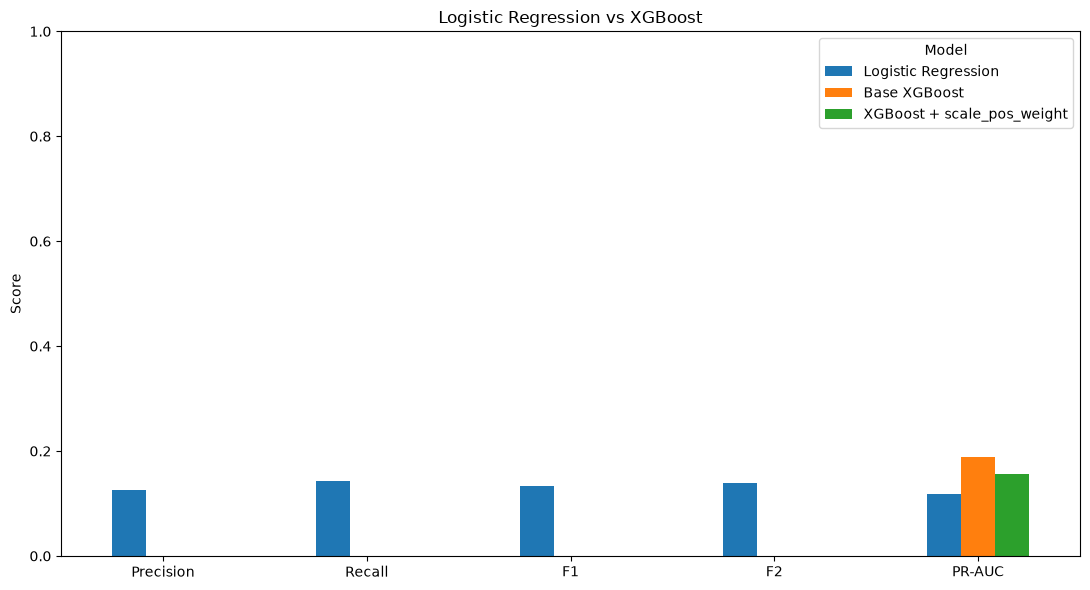

Saved to: ..\results\figures\logistic_vs_xgboost_comparison.png


In [24]:
comparison_metrics = [
    "Precision",
    "Recall",
    "F1",
    "F2",
    "PR-AUC"
]

comparison_results.set_index(
    "Model"
)[
    comparison_metrics
].T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Score")

plt.title(
    "Logistic Regression vs XGBoost"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()

XGB_COMPARISON_PATH = Path(
    "../results/figures/"
    "logistic_vs_xgboost_comparison.png"
)

plt.savefig(
    XGB_COMPARISON_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    XGB_COMPARISON_PATH
)

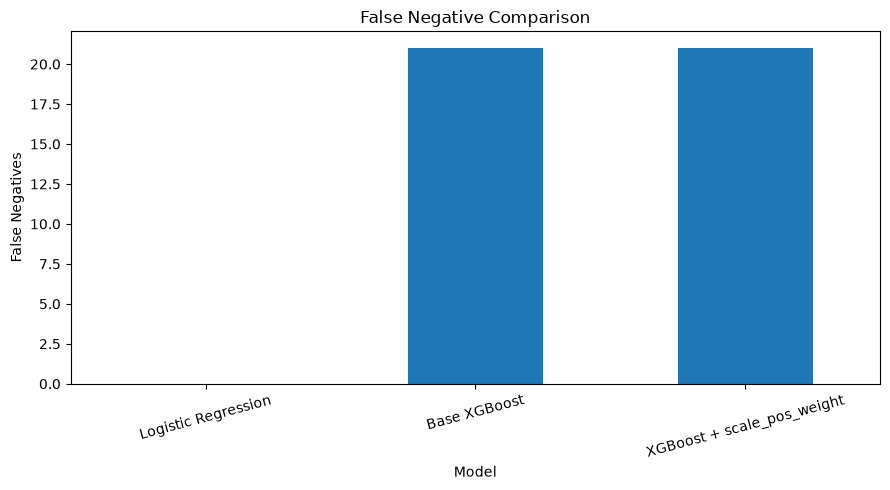

In [25]:
comparison_results.set_index(
    "Model"
)[
    ["False Negatives"]
].plot(
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.ylabel(
    "False Negatives"
)

plt.title(
    "False Negative Comparison"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

XGB_FN_PATH = Path(
    "../results/figures/"
    "xgboost_false_negative_comparison.png"
)

plt.savefig(
    XGB_FN_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

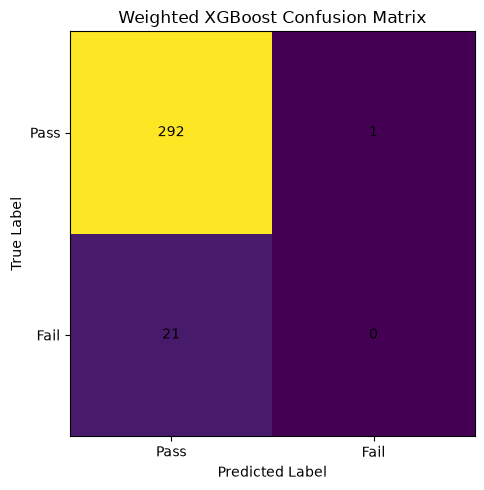

In [26]:
WEIGHTED_XGB_CM_PATH = Path(
    "../results/figures/"
    "weighted_xgboost_confusion_matrix.png"
)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    xgb_weighted_cm
)

plt.title(
    "Weighted XGBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.yticks(
    [0, 1],
    ["Pass", "Fail"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            xgb_weighted_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    WEIGHTED_XGB_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
probability_diagnostic = pd.DataFrame({
    "True Label": y_test.values,
    "Base XGBoost Probability": xgb_base_prob,
    "Weighted XGBoost Probability": xgb_weighted_prob
})

probability_summary = (
    probability_diagnostic
    .groupby("True Label")
    .agg(
        {
            "Base XGBoost Probability": [
                "min",
                "mean",
                "median",
                "max"
            ],
            "Weighted XGBoost Probability": [
                "min",
                "mean",
                "median",
                "max"
            ]
        }
    )
)

probability_summary

Base XGBoost Probability                                \
                                min      mean    median       max   
True Label                                                          
0                          0.000013  0.009971  0.001262  0.599937   
1                          0.000479  0.029610  0.007297  0.198093   

           Weighted XGBoost Probability                                
                                    min      mean    median       max  
True Label                                                             
0                              0.000014  0.015548  0.001243  0.685363  
1                              0.000296  0.031556  0.009103  0.171491

In [33]:
print(
    "Base XGBoost - Fail probabilities:"
)

print(
    pd.Series(
        xgb_base_prob[
            y_test.values == 1
        ]
    ).describe()
)

print(
    "\nHighest Fail probability:",
    xgb_base_prob[
        y_test.values == 1
    ].max()
)

Base XGBoost - Fail probabilities:
count    21.000000
mean      0.029610
std       0.048431
min       0.000479
25%       0.001668
50%       0.007297
75%       0.023551
max       0.198093
dtype: float64

Highest Fail probability: 0.1980928


## 7. XGBoost Feature Importance

XGBoost 모델이 예측 과정에서 상대적으로 많이 활용한
센서 Feature를 확인한다.

Feature Importance가 높다는 것은 모델 예측에 해당 변수가
상대적으로 많이 기여했다는 의미로 해석할 수 있다.

그러나 Feature Importance만으로 해당 센서 변수를
실제 반도체 불량의 물리적인 Root Cause라고 판단할 수는 없다.

SECOM의 Feature가 익명화되어 있으며,
설비, Chamber, Recipe, Lot 등의 공정 정보가 제공되지 않기 때문이다.

따라서 Feature Importance는 모델링 관점의
중요 변수 후보로 해석한다.

In [27]:
weighted_quality_filter = (
    xgb_weighted_pipeline
    .named_steps[
        "quality_filter"
    ]
)

xgb_feature_names = (
    weighted_quality_filter
    .get_feature_names_out()
)

print(
    "Number of features:",
    len(xgb_feature_names)
)

Number of features: 442


In [28]:
weighted_xgb_model = (
    xgb_weighted_pipeline
    .named_steps[
        "model"
    ]
)

feature_importances = (
    weighted_xgb_model
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature":
        xgb_feature_names,

    "Importance":
        feature_importances
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(20)

,Feature,Importance
0,feature_271,0.052714
1,feature_489,0.039908
2,feature_199,0.033460
3,feature_470,0.029925
4,feature_130,0.021333
5,feature_319,0.020673
6,feature_31,0.019765
7,feature_9,0.017719
8,feature_320,0.015331
9,feature_182,0.015285


In [29]:
IMPORTANCE_PATH = Path(
    "../results/metrics/"
    "xgboost_feature_importance.csv"
)

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

print(
    "Saved to:",
    IMPORTANCE_PATH
)

Saved to: ..\results\metrics\xgboost_feature_importance.csv


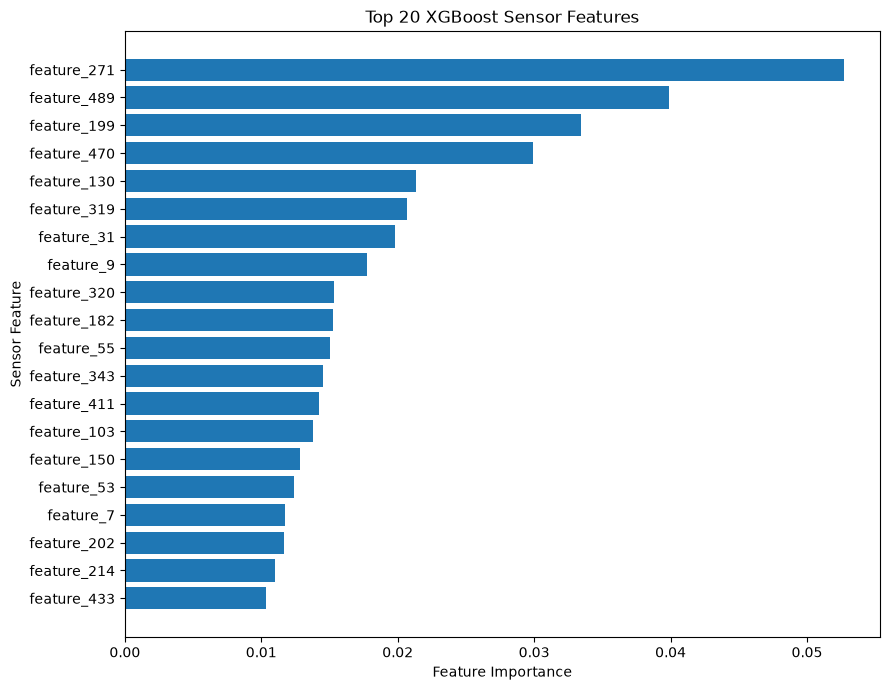

In [30]:
top_importance = (
    importance_df
    .head(20)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(9, 7)
)

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Sensor Feature"
)

plt.title(
    "Top 20 XGBoost Sensor Features"
)

plt.tight_layout()

IMPORTANCE_FIGURE_PATH = Path(
    "../results/figures/"
    "xgboost_top_features.png"
)

plt.savefig(
    IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. XGBoost 종합 결과

본 단계에서는 비선형 Tree Boosting 모델인 XGBoost를 적용하여
기존 Logistic Regression의 한계를 개선할 수 있는지 평가하였다.

또한 심각한 클래스 불균형을 고려하여
Training Data의 Pass/Fail 비율을 기반으로 계산한
`scale_pos_weight=14.0964`를 적용한 모델과 비교하였다.


### 1. 기본 XGBoost 성능

기본 XGBoost의 Test 성능은 다음과 같다.

- Accuracy: **92.99%**
- Precision: **0.00%**
- Recall: **0.00%**
- F1-score: **0.0000**
- F2-score: **0.0000**
- PR-AUC: **0.1881**
- ROC-AUC: **0.7444**

Confusion Matrix는 다음과 같다.

- True Negative: 292개
- False Positive: 1개
- False Negative: 21개
- True Positive: 0개

Accuracy는 약 93%로 높게 나타났으나
실제 Fail 21개를 단 하나도 검출하지 못하였다.

따라서 Accuracy만을 기준으로 판단할 경우
모델 성능을 크게 과대평가할 수 있음을 다시 확인하였다.


### 2. 확률 기반 성능

기본 XGBoost는 기본 임계값에서 Fail을 검출하지 못했지만,
PR-AUC는 0.1881, ROC-AUC는 0.7444로 나타났다.

이는 Baseline Logistic Regression의:

- PR-AUC: 0.1190
- ROC-AUC: 0.6205

보다 높은 결과이다.

따라서 XGBoost가 최종 0/1 분류에서는 Fail을 검출하지 못했더라도,
예측 확률 수준에서는 Pass와 Fail을 구분할 수 있는
일정 수준의 정보를 학습했을 가능성이 있다.

이는 기본 분류 임계값 0.5가 현재 불균형 데이터에
적합하지 않을 가능성을 검토할 필요가 있음을 의미한다.


### 3. `scale_pos_weight` 적용 결과

Training Data의 클래스 분포는:

- Pass: 1,170개
- Fail: 83개

이며 이에 따라 초기 `scale_pos_weight`를 다음과 같이 계산하였다.

`1170 / 83 = 14.0964`

클래스 가중치를 적용한 XGBoost의 성능은 다음과 같다.

- Accuracy: **92.99%**
- Precision: **0.00%**
- Recall: **0.00%**
- F1-score: **0.0000**
- F2-score: **0.0000**
- PR-AUC: **0.1562**
- ROC-AUC: **0.7065**

Confusion Matrix 역시:

- True Negative: 292개
- False Positive: 1개
- False Negative: 21개
- True Positive: 0개

로 기본 XGBoost와 동일하였다.

따라서 현재 XGBoost 설정에서는
`scale_pos_weight=14.0964` 적용만으로 Fail 검출 성능이 개선되지 않았다.

또한 PR-AUC와 ROC-AUC는 기본 XGBoost보다 오히려 감소하였다.


### 4. Logistic Regression과 비교

기존 Logistic Regression은 실제 Fail 21개 중 3개를 검출하여
Recall 14.29%를 기록하였다.

반면 두 XGBoost 모델은 기본 임계값 0.5에서
Fail을 한 개도 검출하지 못하였다.

그러나 기본 XGBoost의 PR-AUC와 ROC-AUC는
Logistic Regression보다 높게 나타났다.

따라서 XGBoost의 비선형 학습 자체가 의미가 없다고 판단하기보다는,
현재 모델의 예측 확률을 최종 클래스에 변환하는
Decision Threshold가 Fail 검출 목적에 적합한지 추가적으로 검토할 필요가 있다.


### 5. XGBoost Feature Importance

Weighted XGBoost의 Feature Importance를 분석한 결과
다음 센서 변수들이 상대적으로 높은 중요도를 보였다.

- feature_271
- feature_489
- feature_199
- feature_470
- feature_130
- feature_319
- feature_31
- feature_9
- feature_320
- feature_182

이 결과는 해당 센서 변수가 XGBoost의 예측 과정에서
상대적으로 많이 활용되었음을 의미한다.

다만 SECOM의 변수는 익명화되어 있으므로
Feature Importance를 실제 공정 불량의 Root Cause로 해석하지 않는다.


## 다음 단계: Decision Threshold 최적화

기본 XGBoost는 Fail Recall이 0으로 나타났지만
PR-AUC와 ROC-AUC에서는 기존 Logistic Regression보다 높은 성능을 보였다.

따라서 Hyperparameter Tuning에 앞서,
Training Data 내부에서 Decision Threshold를 조정하여
Fail 검출 성능의 변화를 분석한다.

다음 단계에서는 다음을 수행한다.

1. Cross Validation 기반 예측 확률 생성
2. 여러 Decision Threshold 비교
3. Fail Recall과 Precision 간 Trade-off 분석
4. F2-score 기반 Threshold 후보 선정
5. 선택된 Threshold를 최종 Test Data에 한 번 적용
6. False Negative 감소 여부 평가

Threshold는 Test Data 성능을 보고 결정하지 않으며,
Training Data 내부에서만 선택하여 Data Leakage를 방지한다.